# Accessibilité et interactivité en dataviz
**Notebook de démonstration — Module Data Visualisation Avancée (M2) — Séance 2**

**Module Data Visualisation (M2 EIA)**

*Enseignant : Jean Delpech*

Version : *Octobre 2026*

---

Ce notebook illustre concrètement les concepts vus en séance/jour 2 : 
* patterns d'interaction
* accessibilité
* éthique

Nous utiliseront principalement **Altair**, sur les mêmes jeux de données que le notebook de la séance 1 (`tips`, `iris`, `penguins`).
 
Chaque fois qu'Altair/Vega-Lite montrera ses limite, un encart **⚠️ Limite d'Altair** l'indique et nomme l'outil plus adapté.

## Sommaire
1. Interactivité : implémenter les patterns de la séance 2
2. Accessibilité : redondance, couleur, contraste, alt-text
3. Synthèse : quand préférer un autre outil qu'Altair


In [1]:
import seaborn as sns
import pandas as pd
import altair as alt # altair a déjà été isntallé à la séance précédente

alt.data_transformers.disable_max_rows()

tips = sns.load_dataset("tips")
iris = sns.load_dataset("iris")
penguins = sns.load_dataset("penguins").dropna()

print("tips :", tips.shape, "| iris :", iris.shape, "| penguins :", penguins.shape)


tips : (244, 7) | iris : (150, 5) | penguins : (333, 7)


# 1. Interactivité : implémenter les patterns de la séance 2

## 1.1 Le mantra de Shneiderman en une seule vue

Quelques lignes suffisent pour implémenter les trois premiers maillons du mantra avec Altair :

* `tooltip` donne les **détails à la demande**
* `.interactive()` ajoute **zoom/pan** (filtrer la zone regardée)
* et le graphique de départ constitue la **vue d'ensemble**

Survolez et zoomez sur le graphique pour apprécier la qualité de l’implémentation.


In [2]:
alt.Chart(penguins).mark_circle(size=70, opacity=0.75).encode(
    x=alt.X("flipper_length_mm:Q", title="Longueur de nageoire (mm)"),
    y=alt.Y("body_mass_g:Q", title="Masse corporelle (g)"),
    color=alt.Color("species:N", title="Espèce"),
    tooltip=["species", "island", "flipper_length_mm", "body_mass_g", "sex"],
).properties(
    title="Overview + zoom/pan + détails à la demande (survolez, zoomez)",
    width=450, height=320,
).interactive()


alt.Chart(...)

## 1.2 Filtres dynamiques (*dynamic query filters*)

Les implémentations les plus classiquues des filtres dynamiques sont les sliders et les menus déroulants pour réduire les données affichées **en
temps réel**, sans rechargement. 

Voici une implémentation directe de ce pattern décrit par Ahlberg, Williamson & Shneiderman (1992) :

In [3]:
mass_slider = alt.param(
    name="mass_min",
    value=3000,
    bind=alt.binding_range(min=2700, max=6300, step=100, name="Masse corporelle min. (g) "),
)

species_select = alt.param(
    name="species_filter",
    value=None,
    bind=alt.binding_select(
        options=[None, "Adelie", "Chinstrap", "Gentoo"],
        labels=["Toutes", "Adelie", "Chinstrap", "Gentoo"],
        name="Espèce ",
    ),
)

alt.Chart(penguins).mark_circle(opacity=0.7).encode(
    x=alt.X("flipper_length_mm:Q", title="Longueur de nageoire (mm)"),
    y=alt.Y("body_mass_g:Q", title="Masse corporelle (g)"),
    color=alt.Color("species:N", title="Espèce"),
).add_params(
    mass_slider, species_select
).transform_filter(
    "datum.body_mass_g >= mass_min"
).transform_filter(
    "!species_filter || datum.species == species_filter"
).properties(title="Filtres dynamiques (slider + menu)", width=450, height=320)


alt.Chart(...)

## 1.3 Brushing & linking

On a déjà vu ce patter d’interaction dans le notebook de la séance 1, pour avoir un aperçu des capaccités d’Altair en la matière. On ajoute ici un indicateur simple.

Une sélection par glisser-déposer (*brush*) dans le nuage de points filtre **simultanément** un histogramme de comptage et une statistique agrégée.
On a donc trois vues sur les données liées par une seule sélection (cf. Becker & Cleveland, 1987).


In [4]:
brush = alt.selection_interval(encodings=["x", "y"])

scatter = alt.Chart(tips).mark_circle(opacity=0.7).encode(
    x=alt.X("total_bill:Q", title="Addition totale ($)"),
    y=alt.Y("tip:Q", title="Pourboire ($)"),
    color=alt.condition(brush, "day:N", alt.value("lightgray")),
).add_params(brush).properties(width=320, height=280, title="1. Sélectionnez une zone")

bars = alt.Chart(tips).mark_bar().encode(
    x=alt.X("day:N", title="Jour", sort=["Thur", "Fri", "Sat", "Sun"]),
    y=alt.Y("count():Q", title="Repas sélectionnés"),
    color="day:N",
).transform_filter(brush).properties(width=200, height=280, title="2. Décompte par jour")

mean_text = alt.Chart(tips).mark_text(size=20, fontWeight="bold").encode(
    text=alt.Text("mean(tip):Q", format=".2f")
).transform_filter(brush).properties(width=150, height=280, title="3. Pourboire moyen ($)")

scatter | bars | mean_text


alt.HConcatChart(...)

## 1.4 Drill-down

Le drill-down donne la possibilité à l’utiliateur de sélection un sous ensemble cohérent (catégorie p. ex.) des données pour « zoomer » dans le dataset.

Ici cliquer sur une barre (vue agrégée) filtre un second graphique montrant le détail du sous-ensemble sélectionné. Il s’agit ici de l'implémentation la plus courante du couple zoom/details-on-demand dans les outils de BI.


In [5]:
click = alt.selection_point(fields=["species"], on="click", empty=True)

overview = alt.Chart(penguins).mark_bar().encode(
    x=alt.X("species:N", title="Espèce"),
    y=alt.Y("count():Q", title="Nombre d'individus"),
    color=alt.condition(click, "species:N", alt.value("lightgray")),
    opacity=alt.condition(click, alt.value(1.0), alt.value(0.4)),
).add_params(click).properties(width=250, height=300, title="1. Cliquez une espèce")

detail = alt.Chart(penguins).mark_circle(opacity=0.7).encode(
    x=alt.X("bill_length_mm:Q", title="Longueur du bec (mm)"),
    y=alt.Y("bill_depth_mm:Q", title="Profondeur du bec (mm)"),
    color=alt.Color("island:N", title="Île"),
).transform_filter(click).properties(width=300, height=300, title="2. Détail de l'espèce")

overview | detail


alt.HConcatChart(...)

## 1.5 Small-multiples/facettes partagant une interaction ?

On tente ici de faire des **small-multiples** (`facet`) où une sélection (brush) faite dans *une* facette filtrerait aussi les autres. C’est un pattern
courant en dashboard (p. ex. : filtrer toutes les vues depuis n'importe laquelle).


In [6]:
brush2 = alt.selection_interval()

alt.Chart(penguins).mark_circle(opacity=0.7).encode(
    x=alt.X("bill_length_mm:Q", title="Longueur du bec (mm)"),
    y=alt.Y("body_mass_g:Q", title="Masse corporelle (g)"),
    color=alt.condition(brush2, "island:N", alt.value("lightgray")),
).add_params(brush2).properties(width=180, height=180).facet(
    column=alt.Column("species:N", title=None)
).properties(title="Un brush par facette (et non partagé entre elles)")


alt.FacetChart(...)

> **⚠️ Limite d'Altair/Vega-Lite (testée ci-dessus) :** avec `.facet()`, chaque facette reçoit sa **propre instance indépendante** du paramètre de sélection. La conséquence est que brosser dans la facette "Adelie" ne filtre pas les facettes "Chinstrap"/"Gentoo".
>
> Pour un vrai filtrage croisé entre petits multiples partageant une seule sélection, il faut juxtaposer des graphiques **indépendants** avec `|`/`&` (comme en 1.3), ce qui marche mais demande de construire chaque vue à la main plutôt que de déclarer un facettage automatique, ce qui contrevient à la logique de la grammarie (mais quand on n’a pas le choix…). L’autre option est de passer à un outil pensé pour du *cross-filtering* natif entre de nombreuses vues : **Superset** ou **Tableau** gèrent ce pattern nativement dans leur interface de dashboard sans contournement.


# 2. Accessibilité

## 2.1 Redondance d'encodage

Une règle fondamentale de l’accessibilité est qu’il ne faut jamais coder une information critique uniquement par la couleur. 

Dans le graphe que nous créons ci-dessous, sur le panneau gauche, l'espèce des pingouins n'est encodée que par la couleur, ce qui devient illisible en niveaux de gris ou pour un-e daltonien-ne. À droite, la **forme** du marqueur redouble l'information : le graphique reste lisible même si la couleur disparaît.


In [7]:
color_only = alt.Chart(penguins).mark_circle(size=70, opacity=0.8).encode(
    x=alt.X("bill_length_mm:Q", title="Longueur du bec (mm)"),
    y=alt.Y("bill_depth_mm:Q", title="Profondeur du bec (mm)"),
    color=alt.Color("species:N", title="Espèce"),
).properties(width=320, height=300, title="Couleur seule")

color_and_shape = alt.Chart(penguins).mark_point(size=70, opacity=0.8, filled=True).encode(
    x=alt.X("bill_length_mm:Q", title="Longueur du bec (mm)"),
    y=alt.Y("bill_depth_mm:Q", title="Profondeur du bec (mm)"),
    color=alt.Color("species:N", title="Espèce"),
    shape=alt.Shape("species:N", title="Espèce"),
).properties(width=320, height=300, title="Couleur + forme (redondant)")

color_only | color_and_shape


alt.HConcatChart(...)

## 2.2 Palette adaptée au daltonisme

La palette catégorielle par défaut de Vega-Lite (Tableau10) n'est pas conçue spécifiquement pour le daltonisme. On va ici la comparer à un sous-ensemble de la
palette **Okabe-Ito**, une référence color-blind-safe en visualisation scientifique.

On appliquera ensuite une **simulation approximative** de déutéranopie (forme la plus fréquente de daltonisme) sur les deux rendus, pour *voir* quelle différence ça fait pour un-e daltonien-ne.

> La matrice utilisée ci-dessous est une approximation pédagogique (transformation directe en espace sRGB), pas une simulation cliniquement validée. Pour un diagnostic fiable sur votre propre travail, utilisez [Coblis](https://www.color-blindness.com/coblis-color-blindness-simulator/), qui implémente un modèle colorimétrique correct.

On va ici utiliser `vl_convert` (présentation sur PiPy):
>vl-convert-python is a dependency-free Python package for converting Vega-Lite chart specifications into static images (SVG or PNG) or Vega chart specifications.
>Since an Altair chart can generate Vega-Lite, this package can be used to easily create static images from Altair charts. 


In [9]:
#!pip install vl_convert_python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 8.7 MB/s  0:00:03 eta 0:00:010:01:01


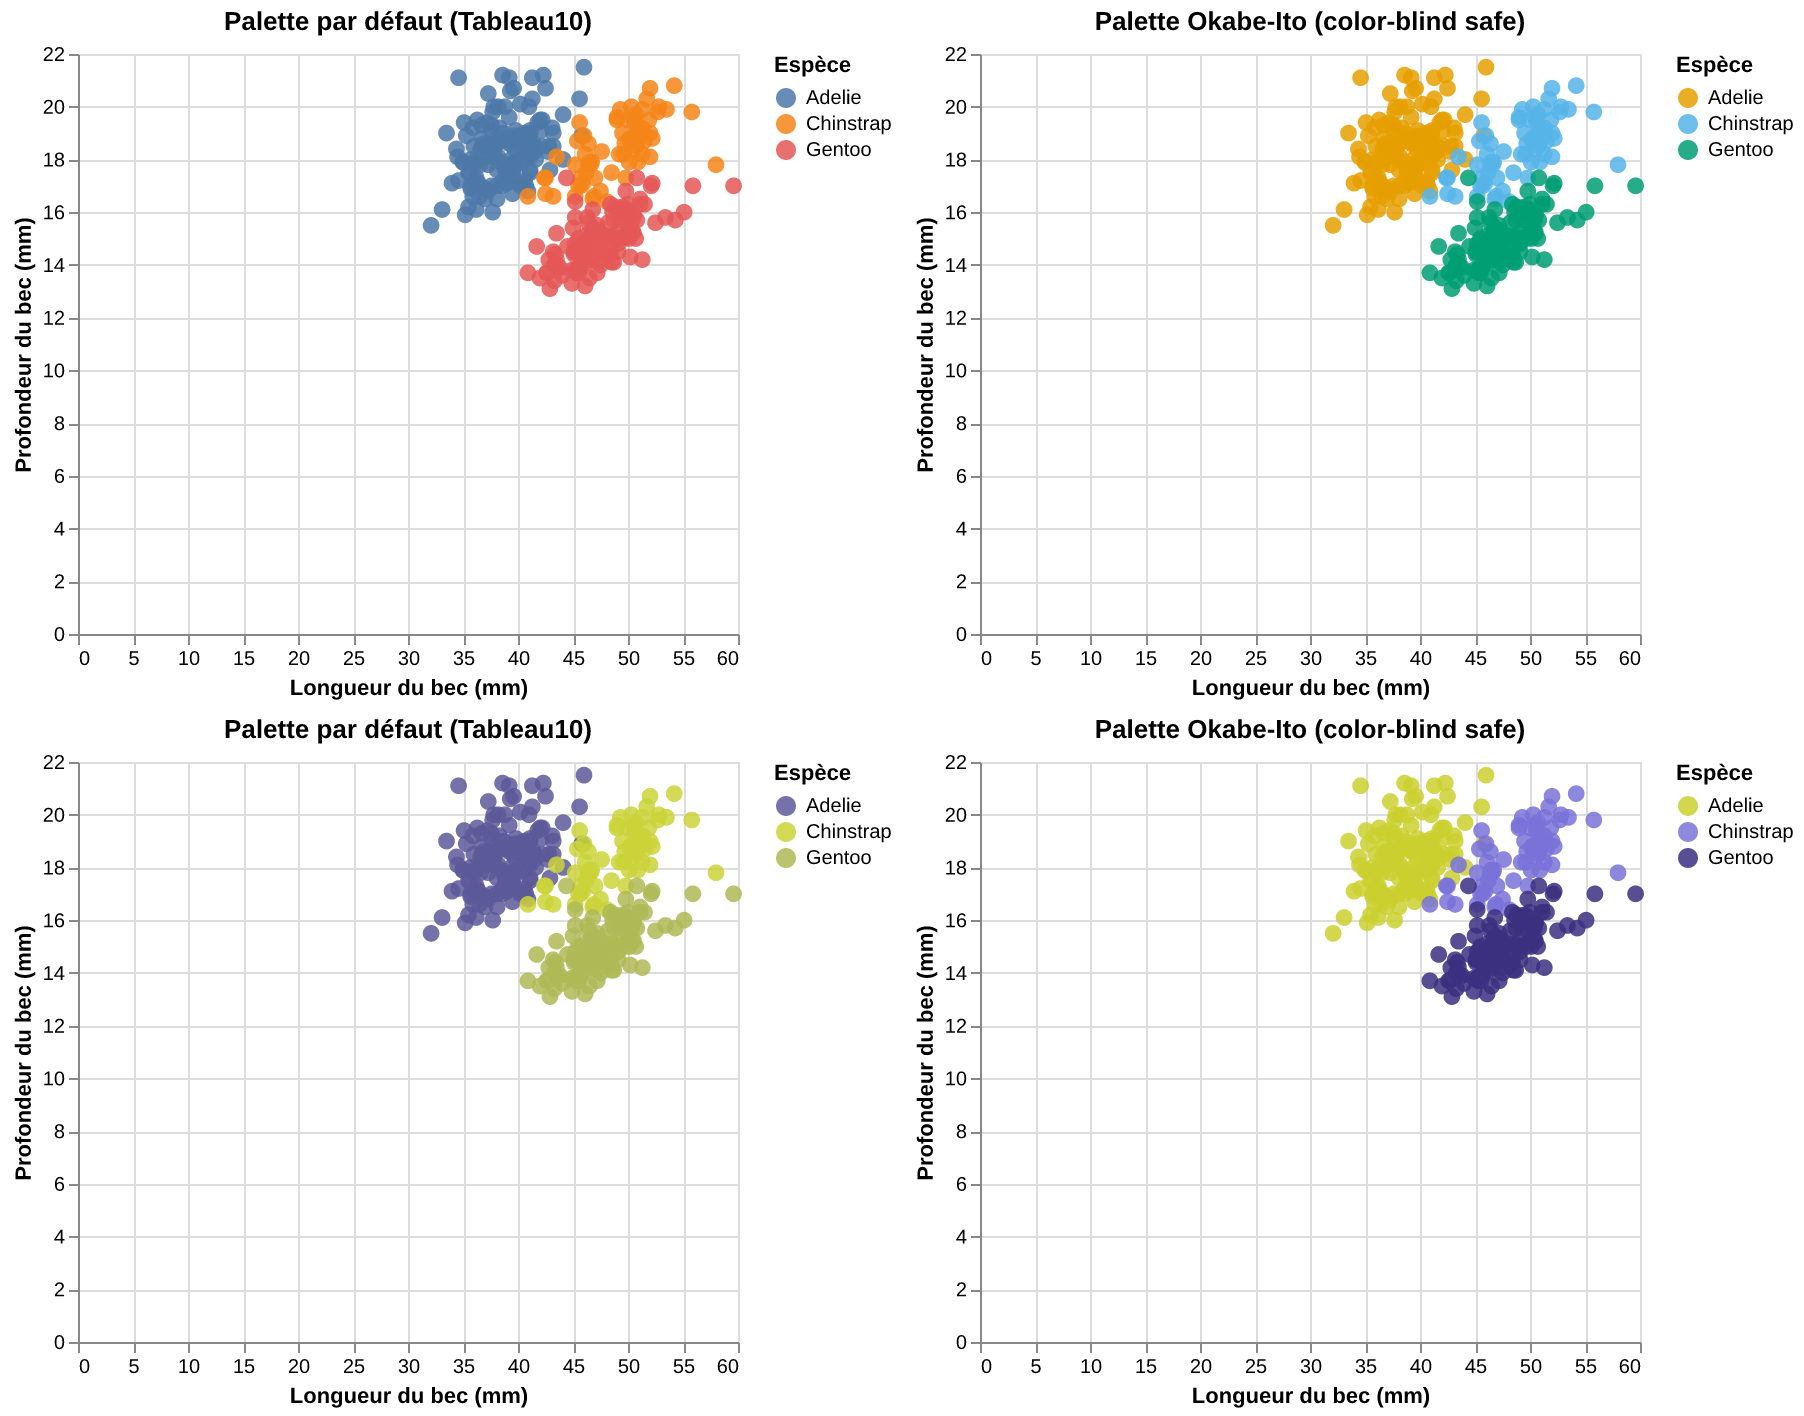

Ligne du haut : vision normale   |   Ligne du bas : déutéranopie simulée
Colonne gauche : palette par défaut   |   Colonne droite : Okabe-Ito


In [10]:
import vl_convert as vlc
import numpy as np
from PIL import Image
import io
from IPython.display import display

# Sous-ensemble de la palette Okabe-Ito (color-blind safe)
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73"]

def make_chart(palette_range=None, title=""):
    enc_color = alt.Color("species:N", title="Espèce")
    if palette_range:
        enc_color = alt.Color("species:N", title="Espèce", scale=alt.Scale(range=palette_range))
    return alt.Chart(penguins).mark_circle(size=70, opacity=0.85).encode(
        x=alt.X("bill_length_mm:Q", title="Longueur du bec (mm)"),
        y=alt.Y("bill_depth_mm:Q", title="Profondeur du bec (mm)"),
        color=enc_color,
    ).properties(width=330, height=290, title=title)

default_chart = make_chart(None, "Palette par défaut (Tableau10)")
okabe_chart = make_chart(OKABE_ITO, "Palette Okabe-Ito (color-blind safe)")

# Matrice d'approximation de la déutéranopie (espace sRGB, usage pédagogique)
DEUTERANOPIA_MATRIX = np.array([
    [0.625, 0.375, 0.000],
    [0.700, 0.300, 0.000],
    [0.000, 0.300, 0.700],
])

def render_png(chart):
    png_bytes = vlc.vegalite_to_png(chart.to_json(), scale=2)
    return Image.open(io.BytesIO(png_bytes)).convert("RGB")

def simulate_deuteranopia(img):
    arr = np.asarray(img).astype(float) / 255.0
    simulated = np.clip(arr @ DEUTERANOPIA_MATRIX.T, 0, 1)
    return Image.fromarray((simulated * 255).astype(np.uint8))

default_img = render_png(default_chart)
okabe_img = render_png(okabe_chart)

default_sim = simulate_deuteranopia(default_img)
okabe_sim = simulate_deuteranopia(okabe_img)

# Montage 2x2 : (normal / simulé) x (défaut / Okabe-Ito)
w, h = default_img.size
montage = Image.new("RGB", (w * 2, h * 2), "white")
montage.paste(default_img, (0, 0))
montage.paste(okabe_img, (w, 0))
montage.paste(default_sim, (0, h))
montage.paste(okabe_sim, (w, h))
display(montage)
print("Ligne du haut : vision normale   |   Ligne du bas : déutéranopie simulée")
print("Colonne gauche : palette par défaut   |   Colonne droite : Okabe-Ito")


Sous simulation, Chinstrap (orange) et Gentoo (rouge) de la palette par défaut deviennent presque la même teinte jaune-olive. Ils restent distinguables ici uniquement parce que leur position diffère (rappel Cleveland & McGill : position > couleur). Avec Okabe-Ito, les trois espèces restent visuellement distinctes même sous simulation.

## 2.3 Vérification du contraste (WCAG)

Être pensée "color-blind safe" ne garantit pas un contraste suffisant, ce sont deux critères différents des WCAG, qu'il faut vérifier séparément. On implémente directement la formule officielle (luminance relative puis ratio de contraste) plutôt que de se fier à l'œil.


In [11]:
def relative_luminance(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))
    def lin(c):
        return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = lin(r), lin(g), lin(b)
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def contrast_ratio(hex1, hex2):
    l1, l2 = relative_luminance(hex1), relative_luminance(hex2)
    l1, l2 = max(l1, l2), min(l1, l2)
    return (l1 + 0.05) / (l2 + 0.05)

palettes = {
    "Tableau10 (défaut)": ["#4c78a8", "#f58518", "#e45756"],
    "Okabe-Ito (subset)": OKABE_ITO,
}

rows = []
for name, colors in palettes.items():
    for c in colors:
        ratio = contrast_ratio(c, "#FFFFFF")
        rows.append({
            "Palette": name,
            "Couleur": c,
            "Contraste vs blanc": round(ratio, 2),
            "Seuil graphique 3:1 (WCAG AA)": "OK" if ratio >= 3 else "Insuffisant",
        })

pd.DataFrame(rows)


,Palette,Couleur,Contraste vs blanc,Seuil graphique 3:1 (WCAG AA)
0,Tableau10 (défaut),#4c78a8,4.61,OK
1,Tableau10 (défaut),#f58518,2.55,Insuffisant
2,Tableau10 (défaut),#e45756,3.62,OK
3,Okabe-Ito (subset),#E69F00,2.25,Insuffisant
4,Okabe-Ito (subset),#56B4E9,2.31,Insuffisant
5,Okabe-Ito (subset),#009E73,3.42,OK


**Résultat notable** : la palette Okabe-Ito, pourtant color-blind safe, échoue au test de contraste 3:1 pour deux de ses trois couleurs sur fond blanc. Il faut donc prévoir d’ajuster (assombrir légèrement) si cette palette doit servir pour du texte ou des éléments fins plutôt que de larges aplats. Daltonisme et contraste sont deux critères indépendants à vérifier séparément.

## 2.4 Texte alternatif (alt-text) intégré au graphique

Vega-Lite (et donc Altair) accepte un champ `description` au niveau du graphique, qui devient l'attribut `aria-label` du SVG produit constituant la première brique, minimale, d'accessibilité pour un lecteur d'écran.


In [12]:
chart_with_alttext = alt.Chart(tips).mark_circle(opacity=0.7).encode(
    x=alt.X("total_bill:Q", title="Addition totale ($)"),
    y=alt.Y("tip:Q", title="Pourboire ($)"),
).properties(
    title="Pourboire vs addition totale",
    description=(
        "Nuage de points : le pourboire augmente globalement avec le montant "
        "de l'addition, suivant une relation à peu près linéaire, avec une "
        "dispersion plus marquée pour les additions élevées."
    ),
    width=400, height=300,
)

import json
spec = json.loads(chart_with_alttext.to_json())
print("Description exposée dans le spec (-> aria-label du SVG) :")
print(spec["description"])
chart_with_alttext


Description exposée dans le spec (-> aria-label du SVG) :
Nuage de points : le pourboire augmente globalement avec le montant de l'addition, suivant une relation à peu près linéaire, avec une dispersion plus marquée pour les additions élevées.


alt.Chart(...)

> **⚠️ Limite d'Altair/Vega-Lite :** ce champ `description` ne décrit que **le graphique entier**, en une seule chaîne, il n'y a hélas pas de description native par point de données, ni de navigation clavier point-par-point pour un lecteur d'écran. Pour une vraie exploration accessible point par point (naviguer aux flèches, entendre chaque valeur individuellement), il faut un outil complémentaire : **Olli** ([mitvis.github.io/olli](https://mitvis.github.io/olli/)), une bibliothèque JS qui prend justement en entrée une spécification Vega-Lite (celle qu'Altair génère) et la convertit en structure arborescente navigable au clavier, conforme ARIA. C'est un bon exemple où l'on ne remplace pas Altair : on le complète.


---
# 3. Synthèse : quand doit-on choisir un autre outil qu'Altair ?

Dans ce notebook a cherché les limites d'Altair. Récapitulatif :

| Besoin rencontré | Limite d'Altair/Vega-Lite observée | Outil plus adapté | Pourquoi |
|---|---|---|---|
| Filtrage croisé entre de nombreux small-multiples | Chaque facette a sa propre instance de sélection ; pas de brush partagé natif entre facettes | **Superset**, **Tableau** | Le *cross-filtering* entre plusieurs vues d'un même dashboard est une fonctionnalité native de l'outil |
| Exploration accessible point par point au clavier/lecteur d'écran  | `description` ne couvre que le graphique entier | **Olli** (en complément) ; sinon **Highcharts**, qui a un module d'accessibilité clavier/lecteur d'écran intégré nativement par défaut | Olli consomme directement une spec Vega-Lite (« chaînon manquant ») |
| Interactivité fluide sur un très gros volume de points | Altair embarque les données dans le JSON de la spec ; au-delà de 5000 lignes il faut explicitement désactiver la limite (`disable_max_rows`, utilisé en cellule 2 de ce notebook), et les performances se dégradent ensuite | **kepler.gl**, **deck.gl**, ou un dashboard BI avec agrégation côté serveur (Superset) | Ces outils rendent en WebGL et/ou agrègent côté serveur, conçus pour des centaines de milliers de points, le navigateur ne reçoit pas toutes les données d’un coup |
| Logique d'interaction très spécifique, non couverte par le vocabulaire des sélections Vega-Lite | Les sélections d'Altair (interval, point) couvrent brushing/linking, drill-down, filtres mais pas n'importe quelle interaction sur-mesure | **D3.js** | Contrôle total du DOM/SVG et des événements, au prix d’un code bien plus long, cf. discussion sur l'écosystème JS |
| Audit d'accessibilité intégré à l'outil, pour un public non développeur | Rien d'intégré : chaque vérification (contraste, redondance) a été faite ici "à la main" en Python | **Power BI** (checklist d'accessibilité intégrée aux rapports) ou **Tableau** | Utile si l'équipe privilégie un outil de BI plutôt que du code pour le projet |

## Conclusion

Le fait qu’il ne gère pas en natif 100% de l’accessibilité ou de l’interactivité ne doit pas nous détourner d’Altair : c'est un bon choix par défaut pour l'interactivité en Python (vu en séance 1), et la plupart des limites listées ci-dessus ne se posent que pour des besoins précis et avancés.
L'essentiel à retenir est la démarche plutôt que la liste : vous devez **tester** qu'une bibliothèque fait réellement ce qu'on lui demande avant de supposer qu'elle le fait et vous retrouver bloqué après avoir bien avancé dans le projet et vous rendre compte qu’il faut trouver une autre solution.
